In [1]:
import re
import os
import json
import pandas as pd
import numpy as np

In [2]:
BASE_PATH = os.getcwd()
DATA_PATH = os.path.join(BASE_PATH, "data")
IMG_DATASET = os.path.join(DATA_PATH, "EXIST 2026 Memes Dataset")
VIDEO_DATASET = os.path.join(DATA_PATH, "EXIST 2026 Videos Dataset")

In [3]:
img_info_file = os.path.join(IMG_DATASET, "training", "EXIST2026_training.json")
with open(img_info_file, "r", encoding="utf-8") as f:
    img_info = json.load(f)

# All data

In [29]:
img_info_file_test = os.path.join(IMG_DATASET, "test", "EXIST2026_test_clean.json")
test_df = pd.read_json(img_info_file_test, orient="index")
test_df.sort_values(by="id_EXIST", inplace=True)
test_df

,id_EXIST,lang,text,meme,path_memes,number_annotators,annotators,gender_annotators,age_annotators,ethnicities_annotators,study_levels_annotators,countries_annotators,split,sensorial
310001,310001,es,Soy como la madre de mi hermano,310001.jpeg,memes/310001.jpeg,6,"[Annotator_888, Annotator_889, Annotator_890, ...","[M, M, M, F, F, F]","[46+, 23-45, 18-22, 46+, 18-22, 23-45]","[White or Caucasian, White or Caucasian, White...","[Master’s degree, Bachelor’s degree, High scho...","[Italy, Spain, Portugal, Mexico, United Kingdo...",TEST-MEME_ES,"{'users': ['ES1', 'ES3'], 'modalities': {'ET':..."
310002,310002,es,DESAFI LLEVAR EN IRÁN LAS AUTORIDADES ESTÁN RE...,310002.jpeg,memes/310002.jpeg,6,"[Annotator_888, Annotator_889, Annotator_890, ...","[M, M, M, F, F, F]","[46+, 23-45, 18-22, 46+, 18-22, 23-45]","[White or Caucasian, White or Caucasian, White...","[Master’s degree, Bachelor’s degree, High scho...","[Italy, Spain, Portugal, Mexico, United Kingdo...",TEST-MEME_ES,"{'users': ['ES3', 'ES8'], 'modalities': {'ET':..."
310003,310003,es,Vincent Vega @VincentVega677-7h D *** YA VIENE...,310003.jpeg,memes/310003.jpeg,6,"[Annotator_888, Annotator_889, Annotator_890, ...","[M, M, M, F, F, F]","[46+, 23-45, 18-22, 46+, 18-22, 23-45]","[White or Caucasian, White or Caucasian, White...","[Master’s degree, Bachelor’s degree, High scho...","[Italy, Spain, Portugal, Mexico, United Kingdo...",TEST-MEME_ES,"{'users': ['ES1', '_GLOBAL_test_EEG_310003_0',..."
310004,310004,es,A ti Mujer soñadora Feliz Día,310004.jpeg,memes/310004.jpeg,6,"[Annotator_888, Annotator_889, Annotator_890, ...","[M, M, M, F, F, F]","[46+, 23-45, 18-22, 46+, 18-22, 23-45]","[White or Caucasian, White or Caucasian, White...","[Master’s degree, Bachelor’s degree, High scho...","[Italy, Spain, Portugal, Mexico, United Kingdo...",TEST-MEME_ES,"{'users': ['ES1', 'ES5'], 'modalities': {'ET':..."
310005,310005,es,Lya Gonzalez @LyaGonzalez1 Aquí hay revolución...,310005.jpeg,memes/310005.jpeg,6,"[Annotator_888, Annotator_889, Annotator_890, ...","[M, M, M, F, F, F]","[46+, 23-45, 18-22, 46+, 18-22, 23-45]","[White or Caucasian, White or Caucasian, White...","[Master’s degree, Bachelor’s degree, High scho...","[Italy, Spain, Portugal, Mexico, United Kingdo...",TEST-MEME_ES,"{'users': ['ES1', 'ES3'], 'modalities': {'ET':..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
410509,410509,en,"WOMEN SHOULDN'T WORK OUTSIDE THE HOME YEAH, RI...",410509.jpeg,memes/410509.jpeg,6,"[Annotator_1102, Annotator_1103, Annotator_196...","[M, M, M, F, F, F]","[18-22, 23-45, 46+, 18-22, 23-45, 46+]","[Black or African American, White or Caucasian...","[High school degree or equivalent, High school...","[South Africa, Belgium, Portugal, Poland, Sout...",TEST-MEME_EN,"{'users': ['EN7', 'ES2'], 'modalities': {'ET':..."
410510,410510,en,"Sa.thousand.apologies ACTUALLY, WOMEN SHOULDN'...",410510.jpeg,memes/410510.jpeg,6,"[Annotator_1102, Annotator_1103, Annotator_196...","[M, M, M, F, F, F]","[18-22, 23-45, 46+, 18-22, 23-45, 46+]","[Black or African American, White or Caucasian...","[High school degree or equivalent, High school...","[South Africa, Belgium, Portugal, Poland, Sout...",TEST-MEME_EN,"{'users': ['EN5', 'ES2'], 'modalities': {'ET':..."
410511,410511,en,Bitches only think you good for sex.. like bit...,410511.jpeg,memes/410511.jpeg,6,"[Annotator_1102, Annotator_1103, Annotator_196...","[M, M, M, F, F, F]","[18-22, 23-45, 46+, 18-22, 23-45, 46+]","[Black or African American, White or Caucasian...","[High school degree or equivalent, High school...","[South Africa, Belgium, Portugal, Poland, Sout...",TEST-MEME_EN,"{'users': ['ES2', '_GLOBAL_test_EEG_410511_0',..."
410512,410512,en,BITCHES BE LOOKING LIKE THIS @ThingsBitchesSay...,410512.jpeg,memes/410512.jpeg,6,"[Annotator_1102, Annotator_1103, Annotator_196...","[M, M, M, F, F, F]","[18-22, 23-45, 46+, 18-22, 23-45, 46+]","[Black or African American, White or Caucasian...","[High school degree or equivalent, High school...","[S

In [31]:
test_df["lang"].value_counts()

lang
es    540
en    513
Name: count, dtype: int64

In [26]:
tabular_df = pd.read_json(img_info_file, orient="index")
tabular_df.sort_values(by="id_EXIST", inplace=True)
tabular_df

,id_EXIST,lang,text,meme,path_memes,number_annotators,annotators,gender_annotators,age_annotators,ethnicities_annotators,study_levels_annotators,countries_annotators,sensorial,labels_task2_1,labels_task2_2,labels_task2_3,split
110001,110001,es,2+2=5 MITO Albert Einstein tenía bajo rendimie...,110001.jpeg,memes/110001.jpeg,6,"[Annotator_1, Annotator_2, Annotator_3, Annota...","[F, F, F, M, M, M]","[18-22, 23-45, 46+, 46+, 18-22, 23-45]","[Hispano or Latino, Hispano or Latino, Hispano...","[High school degree or equivalent, Master’s de...","[Mexico, Spain, Argentina, Spain, Mexico, Mexico]","{'users': ['ES1', 'ES3', 'ES4'], 'modalities':...","[YES, YES, YES, YES, YES, YES]","[DIRECT, DIRECT, DIRECT, DIRECT, DIRECT, DIRECT]","[[IDEOLOGICAL-INEQUALITY, STEREOTYPING-DOMINAN...",TRAIN-MEME_ES
110002,110002,es,CUANDO UNA MUJER VA A LUCHAR POR SUS DERECHOS,110002.jpeg,memes/110002.jpeg,6,"[Annotator_1, Annotator_2, Annotator_3, Annota...","[F, F, F, M, M, M]","[18-22, 23-45, 46+, 46+, 18-22, 23-45]","[Hispano or Latino, Hispano or Latino, Hispano...","[High school degree or equivalent, Master’s de...","[Mexico, Spain, Argentina, Spain, Mexico, Mexico]","{'users': ['ES1', 'ES2', 'ES3', 'ES4'], 'modal...","[YES, YES, YES, YES, YES, YES]","[DIRECT, DIRECT, DIRECT, DIRECT, DIRECT, JUDGE...","[[IDEOLOGICAL-INEQUALITY, STEREOTYPING-DOMINAN...",TRAIN-MEME_ES
110003,110003,es,ІЯ ЕГЕЯ Е MOA ¿El Partido Republicano busca pe...,110003.jpeg,memes/110003.jpeg,6,"[Annotator_1, Annotator_2, Annotator_3, Annota...","[F, F, F, M, M, M]","[18-22, 23-45, 46+, 46+, 18-22, 23-45]","[Hispano or Latino, Hispano or Latino, Hispano...","[High school degree or equivalent, Master’s de...","[Mexico, Spain, Argentina, Spain, Mexico, Mexico]","{'users': ['ES1', 'ES5'], 'modalities': {'ET':...","[YES, YES, NO, NO, NO, NO]","[DIRECT, DIRECT, -, -, -, -]","[[STEREOTYPING-DOMINANCE, OBJECTIFICATION, MIS...",TRAIN-MEME_ES
110004,110004,es,"Paises que ""apoyan"" los derechos de la mujer A...",110004.jpeg,memes/110004.jpeg,6,"[Annotator_1, Annotator_2, Annotator_3, Annota...","[F, F, F, M, M, M]","[18-22, 23-45, 46+, 46+, 18-22, 23-45]","[Hispano or Latino, Hispano or Latino, Hispano...","[High school degree or equivalent, Master’s de...","[Mexico, Spain, Argentina, Spain, Mexico, Mexico]","{'users': ['ES1', 'ES3'], 'modalities': {'ET':...","[YES, YES, NO, NO, YES, NO]","[JUDGEMENTAL, JUDGEMENTAL, -, -, JUDGEMENTAL, -]","[[IDEOLOGICAL-INEQUALITY], [IDEOLOGICAL-INEQUA...",TRAIN-MEME_ES
110005,110005,es,Ya verás como este 8 de marzo hay uno que te s...,110005.jpeg,memes/110005.jpeg,6,"[Annotator_1, Annotator_2, Annotator_3, Annota...","[F, F, F, M, M, M]","[18-22, 23-45, 46+, 46+, 18-22, 23-45]","[Hispano or Latino, Hispano or Latino, Hispano...","[High school degree or equivalent, Master’s de...","[Mexico, Spain, Argentina, Spain, Mexico, Mexico]","{'users': ['ES1', 'ES2', 'ES3', 'ES4'], 'modal...","[NO, YES, NO, NO, YES, NO]","[-, JUDGEMENTAL, -, -, DIRECT, -]","[[-], [IDEOLOGICAL-INEQUALITY], [-], [-], [IDE...",TRAIN-MEME_ES
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
212006,212006,en,u gon act like a bitch u gon die like a bitch,212006.jpeg,memes/212006.jpeg,6,"[Annotator_883, Annotator_884, Annotator_885, ...","[F, F, F, M, M, M]","[18-22, 23-45, 46+, 18-22, 23-45, 46+]","[Black or African American, White or Caucasian...","[Bachelor’s degree, Bachelor’s degree, Bachelo...","[South Africa, Poland, Canada, Poland, Italy, ...","{'users': ['EN1', 'EN2', 'EN3', 'EN5'], 'modal...","[YES, YES, YES, YES, YES, YES]","[DIRECT, DIRECT, JUDGEMENTAL, JUDGEMENTAL, JUD...","[[STEREOTYPING-DOMINANCE, MISOGYNY-NON-SEXUAL-...",TRAIN-MEME_EN
212007,212007,en,SHE LOOKS LIKE EVERY OTHER BITCH LIKE makeamem...,212007.jpeg,memes/212007.jpeg,6,"[Annotator_883, Annotator_884, Annotator_885, ...","[F, F, F, M, M, M]","[18-22, 23-45, 46+, 18-22, 23-45, 46+]","[Black or African American, White or Caucasian...","[Bachelor’s degree, Bachelor’s degree, Bachelo...","[Sout

## Language

In [27]:
tabular_df["lang"].value_counts()

lang
en    2005
es    1979
Name: count, dtype: int64

<Axes: title={'center': 'Language Distribution'}, xlabel='lang'>

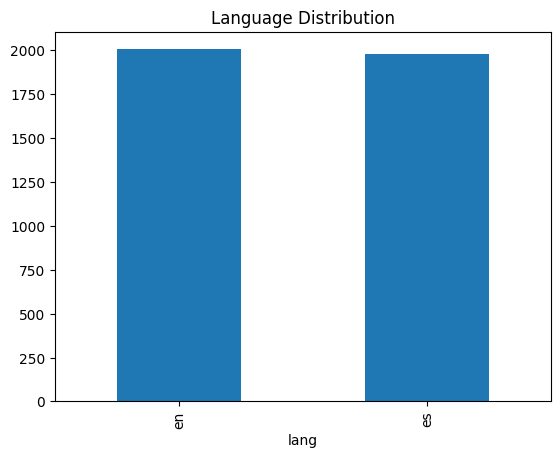

In [6]:
tabular_df["lang"].value_counts().plot(kind="bar", title="Language Distribution")

## Annotators

In [7]:
tabular_df["number_annotators"].value_counts()

number_annotators
6    3984
Name: count, dtype: int64

In [8]:
annotator_columns = [
    "annotators",
    "gender_annotators",
    "age_annotators",
    "ethnicities_annotators",
    "study_levels_annotators",
    "countries_annotators",
]

annotator_df = pd.DataFrame()
for col in annotator_columns:
    annotator_df[col] = tabular_df[col].explode()
annotator_df = annotator_df.drop_duplicates().reset_index(drop=True)
annotator_df.head()

,annotators,gender_annotators,age_annotators,ethnicities_annotators,study_levels_annotators,countries_annotators
0,Annotator_193,F,18-22,White or Caucasian,High school degree or equivalent,Sweden
1,Annotator_194,F,23-45,Multiracial,Master’s degree,United States
2,Annotator_195,F,46+,White or Caucasian,Bachelor’s degree,Spain
3,Annotator_196,M,46+,White or Caucasian,Master’s degree,Portugal
4,Annotator_197,M,18-22,Hispano or Latino,Less than high school diploma,Spain


In [9]:
annotator_df.to_csv(os.path.join(DATA_PATH, "annotators.csv"), index=False)

In [10]:
annotator_df["gender_annotators"].value_counts()

gender_annotators
F    447
M    442
Name: count, dtype: int64

In [11]:
annotator_df["age_annotators"].value_counts()

age_annotators
23-45    298
18-22    297
46+      294
Name: count, dtype: int64

In [12]:
annotator_df["study_levels_annotators"].value_counts()

study_levels_annotators
Bachelor’s degree                   432
High school degree or equivalent    266
Master’s degree                     145
Doctorate                            18
other                                16
Less than high school diploma        12
Name: count, dtype: int64

<Axes: title={'center': 'Top 10 Annotator Countries'}, xlabel='countries_annotators'>

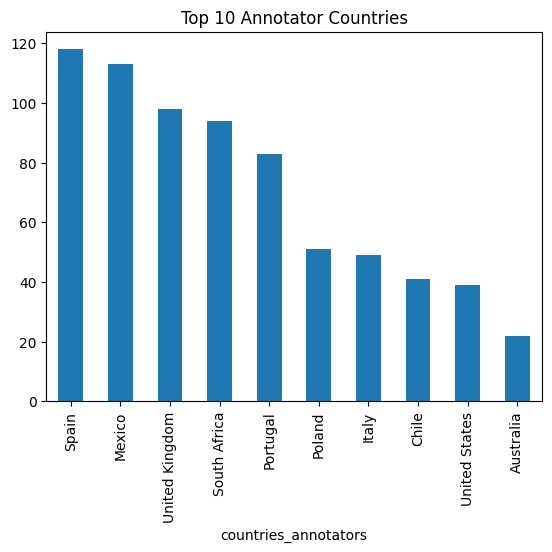

In [13]:
annotator_df["countries_annotators"].value_counts().sort_values(ascending=False).head(
    10
).plot(kind="bar", title="Top 10 Annotator Countries")

## Label / Target

In [14]:
tabular_df

,id_EXIST,lang,text,meme,path_memes,number_annotators,annotators,gender_annotators,age_annotators,ethnicities_annotators,study_levels_annotators,countries_annotators,sensorial,labels_task2_1,labels_task2_2,labels_task2_3,split
110887,110887,es,A VECES QUISIERAIR/ALZUMBA www.facebook.com/Oi...,110887.jpeg,memes/110887.jpeg,6,"[Annotator_193, Annotator_194, Annotator_195, ...","[F, F, F, M, M, M]","[18-22, 23-45, 46+, 46+, 18-22, 23-45]","[White or Caucasian, Multiracial, White or Cau...","[High school degree or equivalent, Master’s de...","[Sweden, United States, Spain, Portugal, Spain...","{'users': ['ES1', 'ES2', 'ES3'], 'modalities':...","[YES, YES, YES, YES, YES, YES]","[JUDGEMENTAL, DIRECT, DIRECT, DIRECT, DIRECT, ...","[[IDEOLOGICAL-INEQUALITY, OBJECTIFICATION], [M...",TRAIN-MEME_ES
110466,110466,es,Se necesita cuidadora para adulto mayor.... fo...,110466.jpeg,memes/110466.jpeg,6,"[Annotator_103, Annotator_104, Annotator_105, ...","[F, F, F, M, M, M]","[18-22, 23-45, 46+, 46+, 18-22, 23-45]","[White or Caucasian, White or Caucasian, Hispa...","[Bachelor’s degree, High school degree or equi...","[Spain, Portugal, Spain, Canada, United States...","{'users': ['ES1', 'ES2', 'ES3'], 'modalities':...","[YES, NO, YES, YES, NO, NO]","[DIRECT, -, DIRECT, DIRECT, -, -]","[[STEREOTYPING-DOMINANCE], [-], [STEREOTYPING-...",TRAIN-MEME_ES
111269,111269,es,tomboy como son el anime y manga pre to tomboy...,111269.jpeg,memes/111269.jpeg,6,"[Annotator_277, Annotator_278, Annotator_279, ...","[F, F, F, M, M, M]","[18-22, 23-45, 46+, 46+, 18-22, 23-45]","[White or Caucasian, Hispano or Latino, other,...","[Bachelor’s degree, Master’s degree, High scho...","[Spain, Spain, Spain, Italy, Spain, Portugal]","{'users': ['ES1', 'ES2', 'ES3'], 'modalities':...","[YES, YES, YES, YES, YES, NO]","[DIRECT, DIRECT, DIRECT, DIRECT, DIRECT, -]","[[OBJECTIFICATION, SEXUAL-VIOLENCE], [OBJECTIF...",TRAIN-MEME_ES
110593,110593,es,HOY QUIERO FELICITAR A TODAS LAS MUJERES DE ES...,110593.jpeg,memes/110593.jpeg,6,"[Annotator_127, Annotator_128, Annotator_129, ...","[F, F, F, M, M, M]","[18-22, 23-45, 46+, 46+, 18-22, 23-45]","[White or Caucasian, Hispano or Latino, White ...","[High school degree or equivalent, Master’s de...","[Poland, Portugal, Spain, United Kingdom, Mexi...","{'users': ['ES1', 'ES3'], 'modalities': {'ET':...","[NO, YES, NO, NO, NO, NO]","[-, JUDGEMENTAL, -, -, -, -]","[[-], [STEREOTYPING-DOMINANCE, OBJECTIFICATION...",TRAIN-MEME_ES
110946,110946,es,DUCHATE GUARRA GRACIAS memegenerator.es,110946.jpeg,memes/110946.jpeg,6,"[Annotator_211, Annotator_212, Annotator_213, ...","[F, F, F, M, M, M]","[18-22, 23-45, 46+, 46+, 18-22, 23-45]","[White or Caucasian, Hispano or Latino, White ...","[Bachelor’s degree, Bachelor’s degree, Bachelo...","[Portugal, Chile, Italy, Portugal, Spain, Chile]","{'users': ['ES1', 'ES2', 'ES3', 'ES4'], 'modal...","[YES, YES, YES, YES, NO, NO]","[DIRECT, DIRECT, DIRECT, DIRECT, -, -]","[[OBJECTIFICATION], [SEXUAL-VIOLENCE], [OBJECT...",TRAIN-MEME_ES
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211246,211246,en,RAMZPAUL @ramzpaul Kristen Dunst wears black t...,211246.jpeg,memes/211246.jpeg,6,"[Annotator_717, Annotator_718, Annotator_719, ...","[F, F, F, M, M, M]","[18-22, 23-45, 46+, 18-22, 23-45, 46+]","[other, Black or African American, White or Ca...","[High school degree or equivalent, Master’s de...","[Morocco, South Africa, United Kingdom, United...","{'users': ['EN1', 'EN2', 'EN3', 'EN5'], 'modal...","[YES, YES, YES, YES, YES, YES]","[JUDGEMENTAL, JUDGEMENTAL, JUDGEMENTAL, DIRECT...","[[IDEOLOGICAL-INEQUALITY, SEXUAL-VIOLENCE], [I...",TRAIN-MEME_EN
211791,211791,en,Girls: OMG I don't know what to wear today Boy...,211791.jpeg,memes/211791.jpeg,6,"[Annotator_835, Annotator_836, Annotator_837, ...","[F, F, F, M, M, M]","[18-22, 23-45, 46+, 18-22, 23-45, 46+]","[Asian, White or Caucasian, White or Caucasian...","[High school degree or equivalent, Master’s de...","[Australia, Hungary, South Afri

In [15]:
tabular_df["labels_task2_1"].value_counts()

labels_task2_1
[YES, YES, YES, YES, YES, YES]    572
[NO, NO, NO, NO, NO, NO]          373
[YES, YES, YES, YES, NO, YES]     169
[YES, YES, YES, NO, YES, YES]     156
[NO, YES, YES, YES, YES, YES]     129
                                 ... 
[YES, NO, NO, YES, NO, YES]        18
[YES, NO, NO, NO, YES, NO]         15
[YES, NO, YES, NO, YES, NO]        14
[NO, NO, NO, YES, YES, NO]         14
[YES, NO, NO, YES, YES, NO]        12
Name: count, Length: 64, dtype: int64

In [16]:
tabular_df["labels_task2_1"].apply(lambda x: x.count("YES") / 6)

110887    1.000000
110466    0.500000
111269    0.833333
110593    0.166667
110946    0.666667
            ...   
211246    1.000000
211791    0.000000
211848    0.333333
210680    0.666667
211643    0.833333
Name: labels_task2_1, Length: 3984, dtype: float64

For `labels_task2_2`, when the predict P(YES) > 0.5 (so we are more confident that the label is YES), we need to choose between sexism types: JUDGEMENTAL, DIRECT, ....

<Axes: title={'center': 'Distribution of YES labels in Task 2.1'}, ylabel='Frequency'>

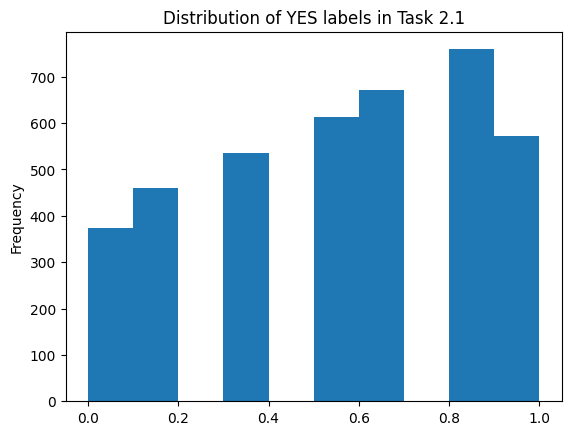

In [25]:
tabular_df["labels_task2_1"].apply(lambda x: x.count("YES") / 6).plot(
    kind="hist", title="Distribution of YES labels in Task 2.1"
)

## Sensors

In [32]:
one_sensor_data = tabular_df["sensorial"].iloc[0]

In [33]:
one_sensor_data.keys()

dict_keys(['users', 'modalities'])

In [34]:
one_sensor_data["users"]

['ES1', 'ES2', 'ES3']

In [36]:
one_sensor_data["modalities"].keys()

dict_keys(['ET', 'HR', 'EEG'])

In [38]:
one_sensor_data["modalities"]["HR"]

{'by_user': {'ES2': {'garmin_hr_mean': 59.7647,
   'garmin_hr_std': 0.6444000000000001,
   'garmin_hr_max': 61.0,
   'garmin_hr_min': 59.0},
  'ES1': {'garmin_hr_mean': 65.5112,
   'garmin_hr_std': 1.9418000000000002,
   'garmin_hr_max': 68.2535,
   'garmin_hr_min': 62.6781}}}

In [39]:
one_sensor_data["modalities"]["EEG"]

{'by_user': {'ES1': {'EXG_Channel_0_Delta_power': -0.5379,
   'EXG_Channel_0_Theta_power': -0.663,
   'EXG_Channel_0_Alpha_power': -0.6211,
   'EXG_Channel_0_Beta_power': -0.42550000000000004,
   'EXG_Channel_0_Gamma_power': -0.5076,
   'EXG_Channel_1_Delta_power': -0.3009,
   'EXG_Channel_1_Theta_power': -0.4187,
   'EXG_Channel_1_Alpha_power': -0.3881,
   'EXG_Channel_1_Beta_power': -0.35100000000000003,
   'EXG_Channel_1_Gamma_power': -0.6171,
   'EXG_Channel_2_Delta_power': -0.2745,
   'EXG_Channel_2_Theta_power': -0.556,
   'EXG_Channel_2_Alpha_power': 0.2154,
   'EXG_Channel_2_Beta_power': -0.4132,
   'EXG_Channel_2_Gamma_power': -1.0264,
   'EXG_Channel_3_Delta_power': -0.1829,
   'EXG_Channel_3_Theta_power': -0.0883,
   'EXG_Channel_3_Alpha_power': 0.5331,
   'EXG_Channel_3_Beta_power': -0.2378,
   'EXG_Channel_3_Gamma_power': -1.0534,
   'EXG_Channel_4_Delta_power': 0.016800000000000002,
   'EXG_Channel_4_Theta_power': -0.1042,
   'EXG_Channel_4_Alpha_power': 0.2836,
   'EXG_C

In [62]:
n_channels = 16
bands = ["Delta", "Theta", "Alpha", "Beta", "Gamma"]

pattern_channel = re.compile(r"EXG_Channel_(\d+)_")
pattern_band = re.compile(r"_(Delta|Theta|Alpha|Beta|Gamma)_power")


def parse_EEG_data(eeg_data: dict):
    eeg_array = np.zeros((n_channels, len(bands)))

    for key, value in eeg_data.items():
        ch = int(pattern_channel.search(key).group(1))
        band = pattern_band.search(key).group(1)
        eeg_array[ch, bands.index(band)] = value

    return eeg_array

In [63]:
eeg_data = parse_EEG_data(one_sensor_data["modalities"]["EEG"]["by_user"]["ES1"])

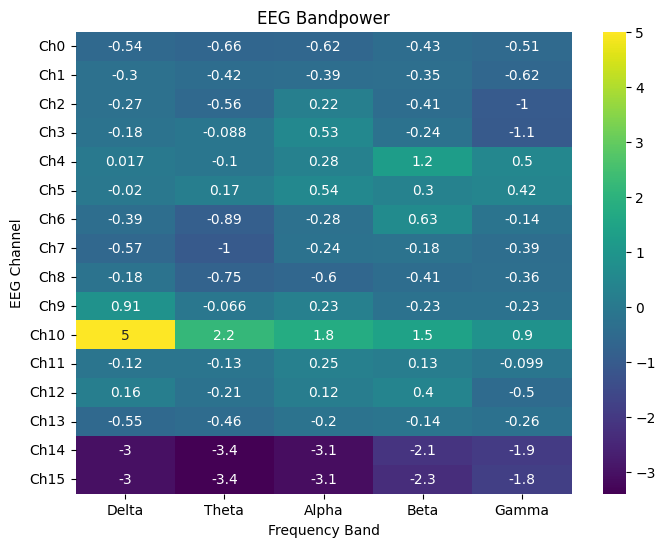

In [64]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

sns.heatmap(
    eeg_data,
    xticklabels=bands,
    yticklabels=[f"Ch{i}" for i in range(16)],
    cmap="viridis",
    annot=True,
)

plt.xlabel("Frequency Band")
plt.ylabel("EEG Channel")
plt.title("EEG Bandpower")
plt.show()

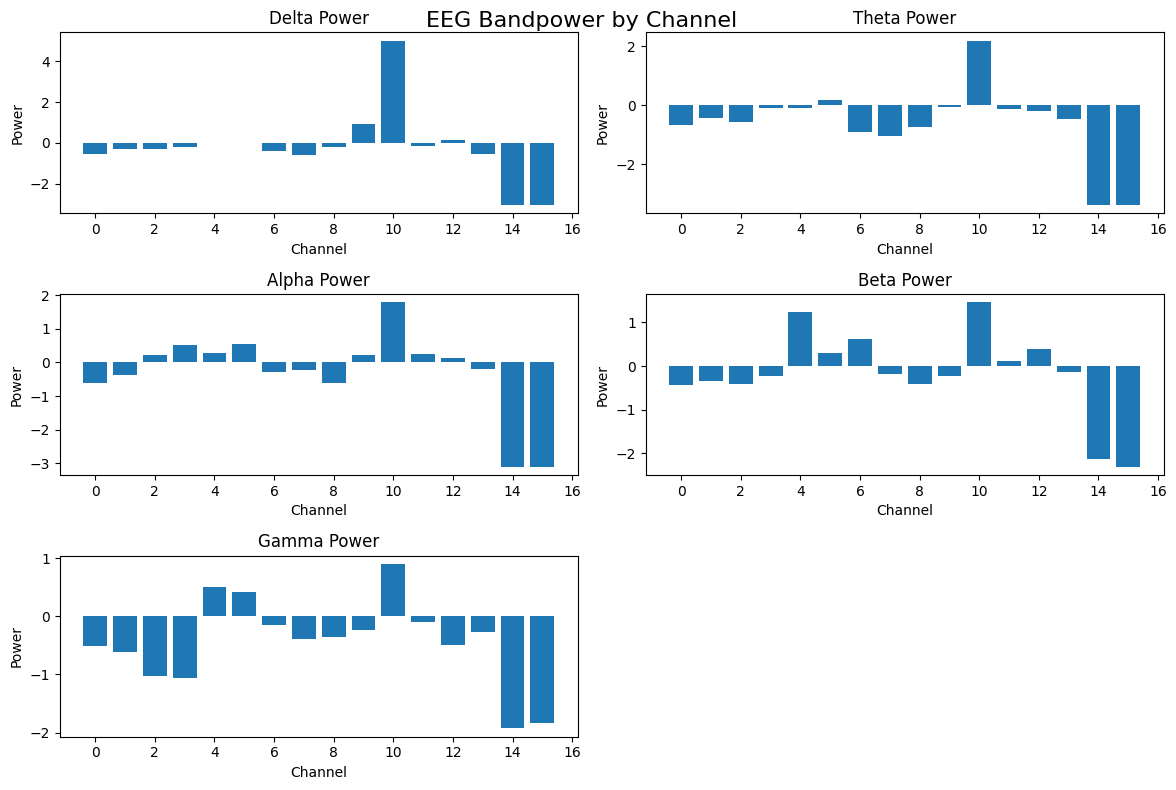

In [73]:
plt.figure(figsize=(12, 8))
for i, band in enumerate(bands):
    plt.subplot(3, 2, i + 1)
    plt.bar(range(16), eeg_data[:, i])
    plt.title(f"{band} Power")
    plt.xlabel("Channel")
    plt.ylabel("Power")
    plt.tight_layout()
plt.suptitle("EEG Bandpower by Channel", fontsize=16)
plt.show()